In [1]:
import os
import numpy as np
import pandas as pd
import astropy.units as u
import matplotlib.pyplot as plt

from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from astroquery.simbad import Simbad
from reproject import reproject_interp
from astroquery.hips2fits import hips2fits
import matplotlib.patheffects as PathEffects
from astropy.wcs.utils import proj_plane_pixel_scales
from matplotlib.patches import Rectangle, FancyArrow, Polygon
from astropy.coordinates import SkyCoord, Angle, SkyOffsetFrame

font = {'family' : 'gill sans',
         'size'   : 12,
         'serif':  'cmr10'
         }

plt.rc('font', **font)
plt.rc('axes', unicode_minus = False)

In [2]:
galaxy_directory = Path().resolve()
galaxy = galaxy_directory.parts[galaxy_directory.parts.index("float-for-morrow") + 1]

In [3]:
records_O = []
records_S = []
records_Fe = []

for region_name in os.listdir(galaxy_directory):
    region_path = galaxy_directory / region_name
    if region_path.name.startswith(".") or not region_path.is_dir():
        continue

    for target_name in os.listdir(region_path):
        target_path = region_path / target_name
        if target_path.name.startswith(".") or target_path.name.startswith("unused") or not target_path.is_dir():
            continue
        target = Simbad.query_object(target_name)
        ra_str  = target["ra"][0]
        dec_str = target["dec"][0]
        coord = SkyCoord(ra_str, dec_str, unit = (u.deg, u.deg), frame = "icrs")
    
        O_path = target_path / "O.txt"
        
        if O_path.is_file():
            
            with open(O_path, "r") as file:
                
                lines = file.readlines()
                OI_H = float(lines[0].strip())
                sigma_OI_H = float(lines[1].strip())
    
            records_O.append({
                    "Target": target_name,
                    "RA": coord.ra.deg,
                    "DEC": coord.dec.deg,
                    "OI_H": OI_H,
                    "sigma_OI_H": sigma_OI_H,
                })
            
        S_path = target_path / "S.txt"
        
        if S_path.is_file():
            
            with open(S_path, "r") as file:
                
                lines = file.readlines()
                SII_H = float(lines[0].strip())
                sigma_SII_H = float(lines[1].strip())
    
            records_S.append({
                    "Target": target_name,
                    "RA": coord.ra.deg,
                    "DEC": coord.dec.deg,
                    "SII_H": SII_H,
                    "sigma_SII_H": sigma_SII_H,
                })
            
        Fe_path = target_path / "Fe.txt"
        
        if Fe_path.is_file():
            
            with open(Fe_path, "r") as file:
                
                lines = file.readlines()
                FeII_H = float(lines[0].strip())
                sigma_FeII_H = float(lines[1].strip())
    
            records_Fe.append({
                    "Region": region_name, 
                    "Target": target_name,
                    "RA": coord.ra.deg,
                    "DEC": coord.dec.deg,
                    "FeII_H": FeII_H,
                    "sigma_FeII_H": sigma_FeII_H,
                })

In [4]:
df_O = pd.DataFrame.from_records(records_O)
df_S = pd.DataFrame.from_records(records_S)
df_Fe = pd.DataFrame.from_records(records_Fe)

In [5]:
df_Fe

,Region,Target,RA,DEC,FeII_H,sigma_FeII_H
0,SMC N88A,2dFS 3694,21.143522,-73.152468,5.713413,0.028138
1,SMC N90,SK 183,22.352284,-73.554541,5.927617,0.027333
2,SMC N66A,Cl* NGC 346 ELS 51,14.786236,-72.170593,5.873223,0.261166
3,SMC N66A,Cl* NGC 346 ELS 50,14.730089,-72.151859,5.735228,0.014690
4,SMC N66A,Cl* NGC 346 MPG 782,14.876602,-72.152674,6.193801,0.069502
5,SMC N66A,Cl* NGC 346 W 3,14.753163,-72.174492,6.184877,0.095107
6,SMC N66A,Cl* NGC 346 W 4,14.750219,-72.177212,5.767586,0.028378
7,SMC N66A,Cl* NGC 346 ELS 22,14.827573,-72.186080,5.896830,0.138110
8,SMC N66A,Cl* NGC 346 SSN 7,14.768732,-72.173540,5.851756,0.024443
9,SMC N66A,Cl* NGC 346 ELS 7,14.739151,-72.176017,6.075540,0.081314


In [6]:
def make_north_up_header(hdu):
    wcs_in = WCS(hdu.header)
    ny, nx = hdu.data.shape
    center_pix = ((nx - 1) / 2.0, (ny - 1) / 2.0)
    center_world = wcs_in.pixel_to_world(*center_pix)

    scales = proj_plane_pixel_scales(wcs_in)

    wcs_target = WCS(naxis = 2)
    wcs_target.wcs.crval = [center_world.ra.deg, center_world.dec.deg]
    wcs_target.wcs.crpix = [ (nx + 1) / 2.0, (ny + 1) / 2.0 ]
    wcs_target.wcs.cdelt = [-scales[0], scales[1]]
    wcs_target.wcs.ctype = ["RA---TAN", "DEC--TAN"]

    header = wcs_target.to_header()
    header["NAXIS1"] = nx
    header["NAXIS2"] = ny
    return header

In [7]:
region_count = 0
region_hdus = []
Simbad.add_votable_fields("dimensions")
for region_name in os.listdir(galaxy_directory):
    region_path = galaxy_directory / region_name
    if region_path.name.startswith(".") or not region_path.is_dir():
        continue
    print(region_name)
    region_query = Simbad.query_object(region_name)
    ra_region = region_query["ra"][0]
    dec_region = region_query["dec"][0]
    majaxis_region = 6
    minaxis_region = 6
    position = SkyCoord(ra_region, dec_region, unit = (u.deg, u.deg), frame = "icrs")
    # hdu_list = hips2fits.query(hips = "CDS/P/DSS2/red", width = 3000, height = 3000, projection = "TAN", ra = position.ra, dec = position.dec, fov = Angle(np.max(np.array([majaxis_region, minaxis_region])) * u.arcmin), format = "fits")

    # Halpha: CDS/P/SHASSA/H
    
    region_count += 1
    # region_hdus.append(hdu_list)

SMC N88A
SMC N90
SMC N66A
SMC N81


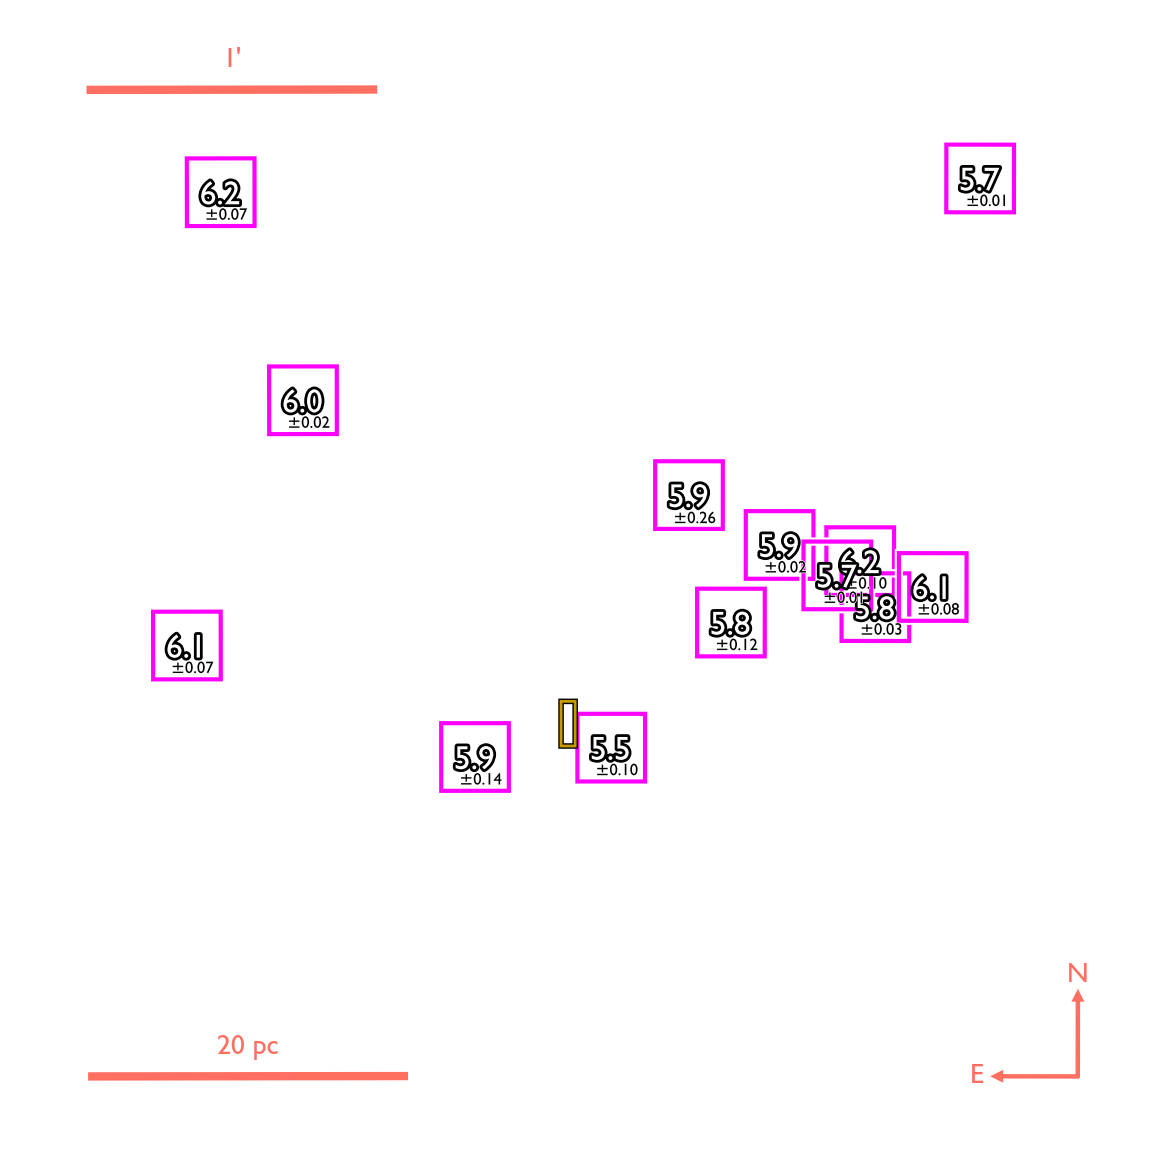

In [8]:
selection = 2

i = 0
for region_name in os.listdir(galaxy_directory):
    region_path = galaxy_directory / region_name
    if region_path.name.startswith(".") or not region_path.is_dir():
        continue
    if i == selection:
        
        df_Fe_cur = df_Fe[df_Fe["Region"] == region_name].copy()
        region_query = Simbad.query_object(region_name)
        ra_region = region_query["ra"][0]
        dec_region = region_query["dec"][0]

        region_position = SkyCoord(ra = ra_region * u.deg, dec = dec_region * u.deg, frame = "icrs")

        hdu_list = fits.open("/Users/billyli/Documents/backups/j92fa3010_drz.fits")

        slit_position = SkyCoord('00h59m14.3s', '-72d11m02.8s', frame = 'icrs')
        hdu_list_background = hips2fits.query(hips = "CDS/P/DSS2/red", width = 3000, height = 3000, projection = "TAN", ra = slit_position.ra - 0.06 * u.arcmin / np.cos(np.deg2rad(slit_position.dec.deg)), dec = slit_position.dec + 0.5 * u.arcmin, fov = Angle(3 * u.arcmin), format = "fits")

        hdu = hdu_list[1]
        hdu_background = hdu_list_background[0]
        wcs = WCS(hdu.header)

        north_up_header = make_north_up_header(hdu_background)
        target_wcs = WCS(north_up_header)
        
        array, footprint = reproject_interp(hdu, target_wcs, shape_out = hdu_background.data.shape)
        array_background, _ = reproject_interp(hdu_background, target_wcs, shape_out = hdu_background.data.shape)
        
        fig = plt.figure(figsize = (6, 6), dpi = 200)
        ax = fig.add_subplot(projection = WCS(north_up_header))
        
        # ax.imshow(array_background, origin = "lower", cmap = "Greys", zorder = -100)
        # ax.imshow(array, origin = "lower", cmap = "Greys", vmax = np.nanpercentile(hdu.data, 99.9))
        
        ra_min = slit_position.ra.deg - 2 / 60 / np.cos(np.deg2rad(slit_position.dec.deg)) - 0.06 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        ra_max = slit_position.ra.deg + 2 / 60 / np.cos(np.deg2rad(slit_position.dec.deg)) - 0.06 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        dec_min = slit_position.dec.deg - 2 / 60 + 0.5 / 60
        dec_max = slit_position.dec.deg + 2 / 60 + 0.5 / 60
        
        x_min, y_min = target_wcs.world_to_pixel(SkyCoord(ra = ra_min * u.deg, dec = dec_min * u.deg))
        x_max, y_max = target_wcs.world_to_pixel(SkyCoord(ra = ra_max * u.deg, dec = dec_max * u.deg))

        if galaxy == "LMC": 
            d = 49.97 * 1000
        elif galaxy == "SMC":
            d = 62.1 * 1000

        block_size_degrees = 0.004

        for _, row in df_Fe_cur.iterrows():
            
            coord = SkyCoord(ra = row["RA"] * u.deg, dec = row["DEC"] * u.deg, frame = "icrs")

            rect = Rectangle((coord.ra.deg - block_size_degrees / 2.0 / np.cos(np.deg2rad(coord.dec.deg)), coord.dec.deg - block_size_degrees / 2.0), block_size_degrees / np.cos(np.deg2rad(coord.dec.deg)), block_size_degrees, linewidth = 1.5, edgecolor = "#ff00ff", facecolor = "none", transform = ax.get_transform("world"))
            rect.set_path_effects([PathEffects.withStroke(linewidth = 3, foreground = "white")])
            ax.add_patch(rect)
            txt = ax.text(coord.ra.deg + 0.00014, coord.dec.deg - 0.00027, f"{row["FeII_H"]:.1f}", fontsize = 12, color = "white", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
            txt.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "black")])
            txt_small = ax.text(coord.ra.deg - 0.0012, coord.dec.deg - 0.0014, r"$\pm$" + f"{row["sigma_FeII_H"]:.2f}", color = "black", fontsize = 6, ha = "center", va = "center", transform = ax.get_transform("world"))
            txt_small.set_path_effects([PathEffects.withStroke(linewidth = 0.5, foreground = "white")])
        
        block_width = 3 / 3600
        block_height = 9.5 / 3600

        slit_position_x_correction = 0
        slit_position_y_correction = 0

        big_rect = Rectangle((slit_position.ra.deg - block_width / 2.0 / np.cos(np.deg2rad(coord.dec.deg)) + slit_position_x_correction, slit_position.dec.deg - block_height / 2.0 + slit_position_y_correction), block_width / np.cos(np.deg2rad(coord.dec.deg)), block_height, linewidth = 1, edgecolor = "#C79900", facecolor = "none", angle = 0, transform = ax.get_transform("world"))
        big_rect.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "black")])
        ax.add_patch(big_rect)

        # text = ax.text(slit_position.ra.deg + slit_position_x_correction, slit_position.dec.deg + slit_position_y_correction + 0.003, r"$[5.17\pm0.03, 5.26\pm0.02]$", fontsize = 12, color = "black", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        # text.set_path_effects([PathEffects.withStroke(linewidth = 4, foreground = "white")])

        scalebar_length = 20
        scalebar_length_degrees = (scalebar_length / d) * (180.0 / np.pi)
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_length_degrees / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "#ff6f61", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_length_degrees / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_length} pc", color = "#ff6f61", fontsize = 10, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))

        scalebar_angle_length = 1
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_max - 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_angle_length / 60 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "#ff6f61", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_angle_length / 60 / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_angle_length}'", color = "#ff6f61", fontsize = 10, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))
        
        arrow_x, arrow_y = ra_min + 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60

        arrow_north = FancyArrow(arrow_x, arrow_y, 0, 0.3 / 60, transform = ax.get_transform("world"), width = 0.0001 / np.cos(np.deg2rad(region_position.dec.deg)), head_width = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), head_length = 0.0005, length_includes_head = True, color = "#ff6f61", clip_on = False)
        arrow_east = FancyArrow(arrow_x, arrow_y, 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), 0, transform = ax.get_transform("world"), width = 0.0001, head_width = 0.0005, head_length = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), length_includes_head = True, color = "#ff6f61", clip_on = False)
        
        ax.add_patch(arrow_north)
        ax.add_patch(arrow_east)

        ax.text(arrow_x, arrow_y + 0.3 / 60 + 0.001, "N", color = "#ff6f61", fontsize = 10, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        ax.text(arrow_x + 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)) + 0.001 / np.cos(np.deg2rad(region_position.dec.deg)), arrow_y, "E", color = "#ff6f61", fontsize = 10, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))

        ax.set_aspect("equal")
        # ax.set_title(r"SMC N66A")
        
        for coord in ax.coords:
            coord.set_ticks_visible(False)
            coord.set_ticklabel_visible(False)
            coord.set_axislabel("")

        ax.set_facecolor("none")
        fig.patch.set_alpha(0.0)
        ax.axis("off")
        
        ax.set_xlim(x_max, x_min)
        ax.set_ylim(y_min, y_max)
        
        plt.tight_layout()
        plt.savefig(
            "Poster figure overlay.png",
            dpi = 300,
            bbox_inches = "tight",
            transparent = True
        )
        plt.show()
        
    i += 1

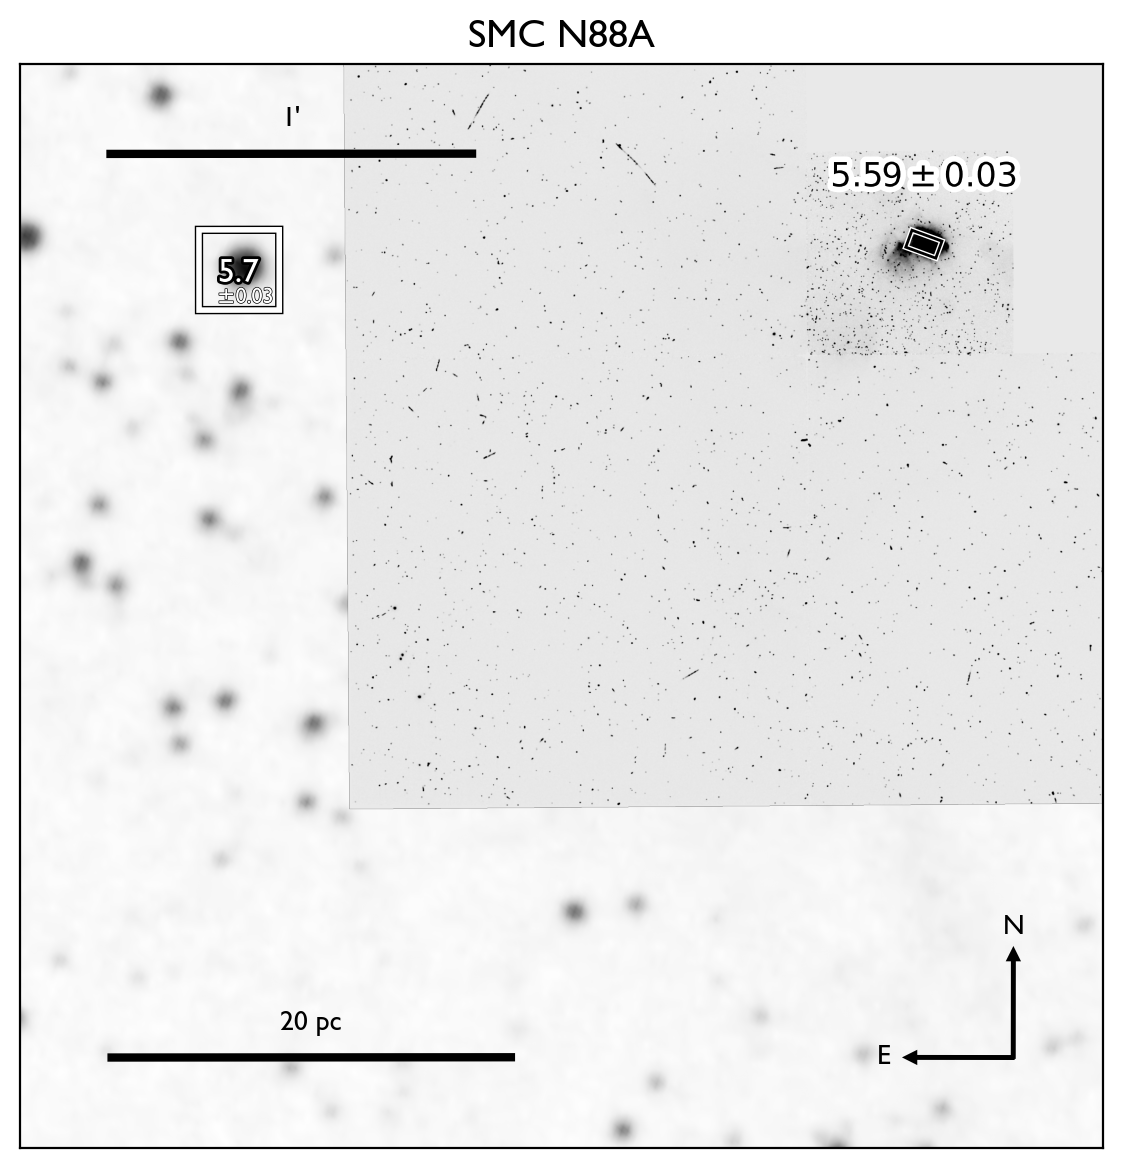

In [9]:
selection = 0

i = 0
for region_name in os.listdir(galaxy_directory):
    region_path = galaxy_directory / region_name
    if region_path.name.startswith(".") or not region_path.is_dir():
        continue
    if i == selection:
        
        df_Fe_cur = df_Fe[df_Fe["Region"] == region_name].copy()
        region_query = Simbad.query_object(region_name)
        ra_region = region_query["ra"][0]
        dec_region = region_query["dec"][0]

        region_position = SkyCoord(ra = ra_region * u.deg, dec = dec_region * u.deg, frame = "icrs")

        hdu_list = fits.open("/Users/billyli/Documents/backups/u3yo030sr_drz.fits")

        slit_position = SkyCoord('01h24m08.3s', '−73d09m04.6s', frame = 'icrs')
        hdu_list_background = hips2fits.query(hips = "CDS/P/DSS2/red", width = 3000, height = 3000, projection = "TAN", ra = slit_position.ra + 1 * u.arcmin / np.cos(np.deg2rad(slit_position.dec.deg)), dec = slit_position.dec - 1 * u.arcmin, fov = Angle(3 * u.arcmin), format = "fits")
        
        hdu = hdu_list[1]
        hdu_background = hdu_list_background[0]
        wcs = WCS(hdu.header)

        north_up_header = make_north_up_header(hdu_background)
        target_wcs = WCS(north_up_header)
        
        array, footprint = reproject_interp(hdu, target_wcs, shape_out = hdu_background.data.shape)
        array_background, _ = reproject_interp(hdu_background, target_wcs, shape_out = hdu_background.data.shape)
        
        fig = plt.figure(figsize = (6, 6), dpi = 200)
        ax = fig.add_subplot(projection = WCS(north_up_header))
        
        ax.imshow(array_background, origin = "lower", cmap = "Greys", zorder = -100)
        ax.imshow(array, origin = "lower", cmap = "Greys", vmax = np.nanpercentile(hdu.data, 99.7))
        
        ra_min = slit_position.ra.deg - 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg)) + 1 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        ra_max = slit_position.ra.deg + 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg)) + 1 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        dec_min = slit_position.dec.deg - 1.5 / 60 - 1 / 60
        dec_max = slit_position.dec.deg + 1.5 / 60 - 1 / 60
        
        x_min, y_min = target_wcs.world_to_pixel(SkyCoord(ra = ra_min * u.deg, dec = dec_min * u.deg))
        x_max, y_max = target_wcs.world_to_pixel(SkyCoord(ra = ra_max * u.deg, dec = dec_max * u.deg))

        if galaxy == "LMC": 
            d = 49.97 * 1000
        elif galaxy == "SMC":
            d = 62.1 * 1000

        block_size_degrees = 0.0037

        for _, row in df_Fe_cur.iterrows():
            
            coord = SkyCoord(ra = row["RA"] * u.deg, dec = row["DEC"] * u.deg, frame = "icrs")

            rect = Rectangle((coord.ra.deg - block_size_degrees / 2.0 / np.cos(np.deg2rad(coord.dec.deg)), coord.dec.deg - block_size_degrees / 2.0), block_size_degrees / np.cos(np.deg2rad(coord.dec.deg)), block_size_degrees, linewidth = 2, edgecolor = "white", facecolor = "none", transform = ax.get_transform("world"), clip_on = False)
            rect.set_path_effects([PathEffects.withStroke(linewidth = 3, foreground = "black")])
            ax.add_patch(rect)
            txt = ax.text(coord.ra.deg + 0.0001, coord.dec.deg - 0.0002, f"{row["FeII_H"]:.1f}", fontsize = 12, color = "white", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world")) # adjusted for centering
            txt.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "black")])
            txt_small = ax.text(coord.ra.deg - 0.001, coord.dec.deg - 0.0013, r"$\pm$" + f"{row["sigma_FeII_H"]:.2f}", color = "white", fontsize = 8, ha = "center", va = "center", transform = ax.get_transform("world")) # adjusted for centering
            txt_small.set_path_effects([PathEffects.withStroke(linewidth = 0.5, foreground = "black")])
        
        block_width = 3 / 3600
        block_height = 5.3 / 3600

        slit_position_x_correction = 0
        slit_position_y_correction = 0

        offset_frame = SkyOffsetFrame(origin = slit_position)
        rect_half_width = block_width / 2.0
        rect_half_height = block_height / 2.0
        corner_offsets = [[-rect_half_width, -rect_half_height], [ rect_half_width, -rect_half_height], [ rect_half_width,  rect_half_height], [-rect_half_width,  rect_half_height]]
        
        angle_rad = np.deg2rad(110)
        rotated_offsets = [[x * np.cos(angle_rad) - y * np.sin(angle_rad), x * np.sin(angle_rad) + y * np.cos(angle_rad)] for x, y in corner_offsets]

        corner_coords = SkyCoord([x for x, y in rotated_offsets] * u.deg, [y for x, y in rotated_offsets] * u.deg, frame = offset_frame).transform_to('icrs')
        polygon_vertices = [(coord.ra.deg, coord.dec.deg) for coord in corner_coords]
        poly = Polygon(polygon_vertices, closed = True, edgecolor = "black", facecolor = "none", linewidth = 1, transform = ax.get_transform("world"))
        poly.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "white")])
        ax.add_patch(poly)

        text = ax.text(slit_position.ra.deg + slit_position_x_correction, slit_position.dec.deg + slit_position_y_correction + 0.003, r"$5.59\pm0.03$", fontsize = 12, color = "black", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        text.set_path_effects([PathEffects.withStroke(linewidth = 4, foreground = "white")])
        
        ax.set_aspect("equal")
        ax.set_title(r"SMC N88A")

        scalebar_length = 20
        scalebar_length_degrees = (scalebar_length / d) * (180.0 / np.pi)
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_length_degrees / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_length_degrees / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_length} pc", color = "black", fontsize = 10, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))

        scalebar_angle_length = 1
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_max - 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_angle_length / 60 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_angle_length / 60 / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_angle_length}'", color = "black", fontsize = 10, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))
        
        arrow_x, arrow_y = ra_min + 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60

        arrow_north = FancyArrow(arrow_x, arrow_y, 0, 0.3 / 60, transform = ax.get_transform("world"), width = 0.0001 / np.cos(np.deg2rad(region_position.dec.deg)), head_width = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), head_length = 0.0005, length_includes_head = True, color = "black", clip_on = False)
        arrow_east = FancyArrow(arrow_x, arrow_y, 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), 0, transform = ax.get_transform("world"), width = 0.0001, head_width = 0.0005, head_length = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), length_includes_head = True, color = "black", clip_on = False)
        
        ax.add_patch(arrow_north)
        ax.add_patch(arrow_east)

        ax.text(arrow_x, arrow_y + 0.3 / 60 + 0.001, "N", color = "black", fontsize = 10, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        ax.text(arrow_x + 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)) + 0.001 / np.cos(np.deg2rad(region_position.dec.deg)), arrow_y, "E", color = "black", fontsize = 10, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        
        for coord in ax.coords:
            coord.set_ticks_visible(False)
            coord.set_ticklabel_visible(False)
            coord.set_axislabel("")

        ax.set_xlim(x_max, x_min)
        ax.set_ylim(y_min, y_max)
            
        plt.tight_layout()
        plt.savefig('SMC N88A.png', dpi = 300)
        plt.show()
        
    i += 1

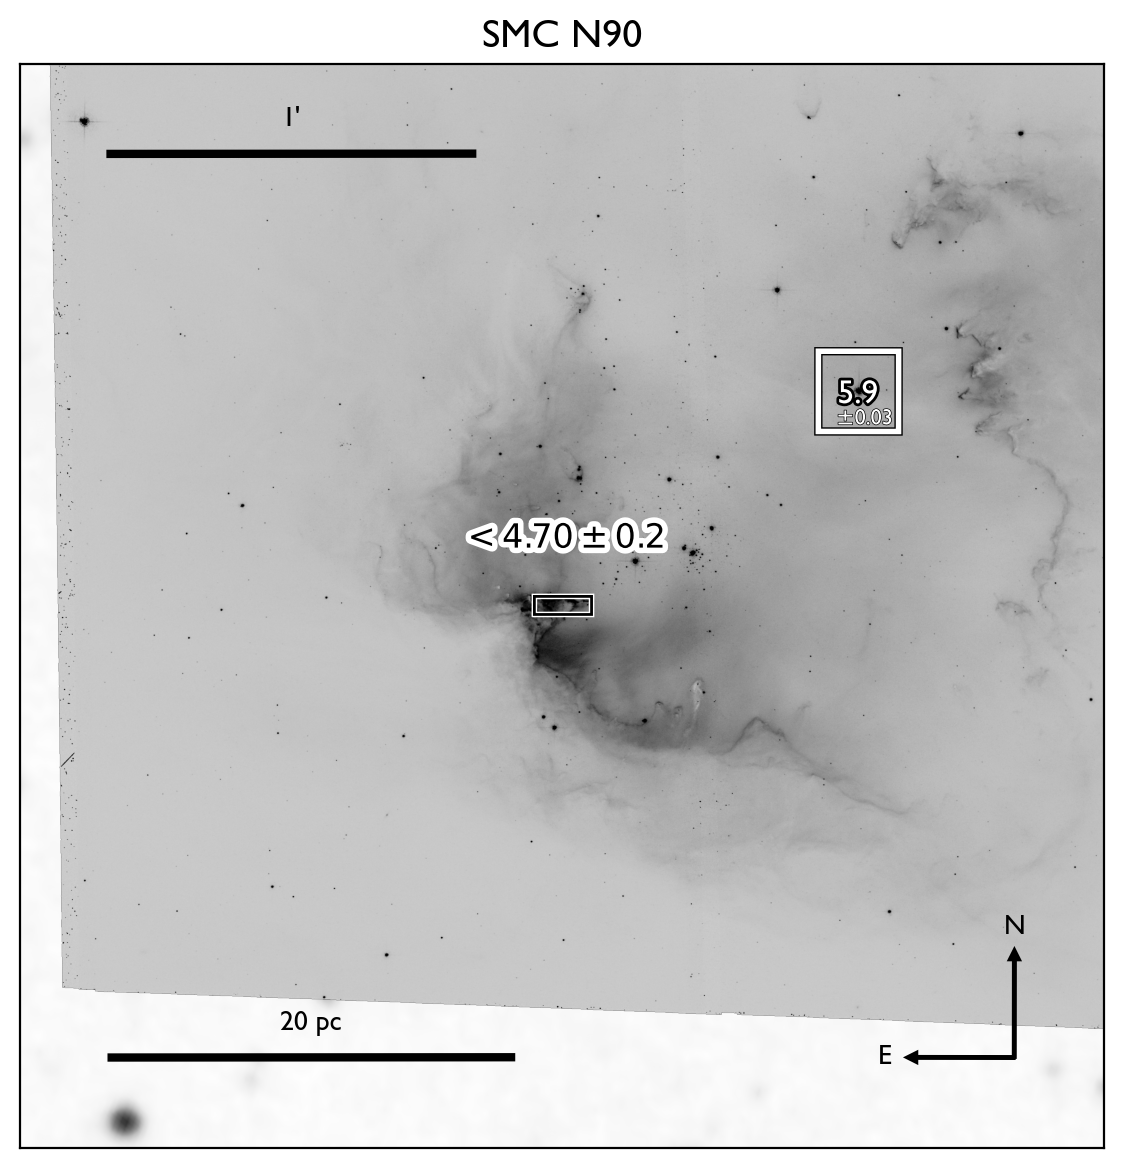

In [10]:
selection = 1

i = 0
for region_name in os.listdir(galaxy_directory):
    region_path = galaxy_directory / region_name
    if region_path.name.startswith(".") or not region_path.is_dir():
        continue
    if i == selection:
        
        df_Fe_cur = df_Fe[df_Fe["Region"] == region_name].copy()
        region_query = Simbad.query_object(region_name)
        ra_region = region_query["ra"][0]
        dec_region = region_query["dec"][0]

        region_position = SkyCoord(ra = ra_region * u.deg, dec = dec_region * u.deg, frame = "icrs")

        hdu_list = fits.open("/Users/billyli/Documents/backups/j92fa6010_drz.fits")

        slit_position = SkyCoord('01h29m36.1s', '−73d33m51.9s', frame = 'icrs')
        hdu_list_background = hips2fits.query(hips = "CDS/P/DSS2/red", width = 3000, height = 3000, projection = "TAN", ra = slit_position.ra, dec = slit_position.dec, fov = Angle(3 * u.arcmin), format = "fits")

        hdu = hdu_list[1]
        hdu_background = hdu_list_background[0]
        wcs = WCS(hdu.header)

        north_up_header = make_north_up_header(hdu_background)
        target_wcs = WCS(north_up_header)
        
        array, footprint = reproject_interp(hdu, target_wcs, shape_out = hdu_background.data.shape)
        array_background, _ = reproject_interp(hdu_background, target_wcs, shape_out = hdu_background.data.shape)
        
        fig = plt.figure(figsize = (6, 6), dpi = 200)
        ax = fig.add_subplot(projection = WCS(north_up_header))
        
        ax.imshow(array_background, origin = "lower", cmap = "Greys", zorder = -100)
        ax.imshow(array, origin = "lower", cmap = "Greys", vmax = np.nanpercentile(hdu.data, 99.93))
        
        ra_min = slit_position.ra.deg - 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        ra_max = slit_position.ra.deg + 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        dec_min = slit_position.dec.deg - 1.5 / 60
        dec_max = slit_position.dec.deg + 1.5 / 60
        
        x_min, y_min = target_wcs.world_to_pixel(SkyCoord(ra = ra_min * u.deg, dec = dec_min * u.deg))
        x_max, y_max = target_wcs.world_to_pixel(SkyCoord(ra = ra_max * u.deg, dec = dec_max * u.deg))

        if galaxy == "LMC": 
            d = 49.97 * 1000
        elif galaxy == "SMC":
            d = 62.1 * 1000

        block_size_degrees = 0.0037

        for _, row in df_Fe_cur.iterrows():
            
            coord = SkyCoord(ra = row["RA"] * u.deg, dec = row["DEC"] * u.deg, frame = "icrs")

            rect = Rectangle((coord.ra.deg - block_size_degrees / 2.0 / np.cos(np.deg2rad(coord.dec.deg)), coord.dec.deg - block_size_degrees / 2.0), block_size_degrees / np.cos(np.deg2rad(coord.dec.deg)), block_size_degrees, linewidth = 2, edgecolor = "white", facecolor = "none", transform = ax.get_transform("world"), clip_on = False)
            rect.set_path_effects([PathEffects.withStroke(linewidth = 3, foreground = "black")])
            ax.add_patch(rect)
            txt = ax.text(coord.ra.deg + 0.0001, coord.dec.deg - 0.0002, f"{row["FeII_H"]:.1f}", fontsize = 12, color = "white", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world")) # adjusted for centering
            txt.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "black")])
            txt_small = ax.text(coord.ra.deg - 0.001, coord.dec.deg - 0.0013, r"$\pm$" + f"{row["sigma_FeII_H"]:.2f}", color = "white", fontsize = 8, ha = "center", va = "center", transform = ax.get_transform("world")) # adjusted for centering
            txt_small.set_path_effects([PathEffects.withStroke(linewidth = 0.5, foreground = "black")])
            
        block_width = 9.5 / 3600
        block_height = 3 / 3600

        slit_position_x_correction = 0
        slit_position_y_correction = 0

        big_rect = Rectangle((slit_position.ra.deg - block_width / 2.0 / np.cos(np.deg2rad(coord.dec.deg)) + slit_position_x_correction, slit_position.dec.deg - block_height / 2.0 + slit_position_y_correction), block_width / np.cos(np.deg2rad(coord.dec.deg)), block_height, linewidth = 1, edgecolor = "black", facecolor = "none", angle = 0, transform = ax.get_transform("world"), clip_on = False)
        big_rect.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "white")])
        ax.add_patch(big_rect)

        text = ax.text(slit_position.ra.deg + slit_position_x_correction, slit_position.dec.deg + slit_position_y_correction + 0.003, r"$<4.70\pm0.2$", fontsize = 12, color = "black", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        text.set_path_effects([PathEffects.withStroke(linewidth = 4, foreground = "white")])

        scalebar_length = 20
        scalebar_length_degrees = (scalebar_length / d) * (180.0 / np.pi)
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_length_degrees / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_length_degrees / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_length} pc", color = "black", fontsize = 10, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))

        scalebar_angle_length = 1
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_max - 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_angle_length / 60 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_angle_length / 60 / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_angle_length}'", color = "black", fontsize = 10, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))
        
        arrow_x, arrow_y = ra_min + 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60

        arrow_north = FancyArrow(arrow_x, arrow_y, 0, 0.3 / 60, transform = ax.get_transform("world"), width = 0.0001 / np.cos(np.deg2rad(region_position.dec.deg)), head_width = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), head_length = 0.0005, length_includes_head = True, color = "black", clip_on = False)
        arrow_east = FancyArrow(arrow_x, arrow_y, 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), 0, transform = ax.get_transform("world"), width = 0.0001, head_width = 0.0005, head_length = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), length_includes_head = True, color = "black", clip_on = False)
        
        ax.add_patch(arrow_north)
        ax.add_patch(arrow_east)

        ax.text(arrow_x, arrow_y + 0.3 / 60 + 0.001, "N", color = "black", fontsize = 10, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        ax.text(arrow_x + 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)) + 0.001 / np.cos(np.deg2rad(region_position.dec.deg)), arrow_y, "E", color = "black", fontsize = 10, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))

        ax.set_aspect("equal")
        ax.set_title(r"SMC N90")
        
        for coord in ax.coords:
            coord.set_ticks_visible(False)
            coord.set_ticklabel_visible(False)
            coord.set_axislabel("")

        ax.set_xlim(x_max, x_min)
        ax.set_ylim(y_min, y_max)
            
        plt.tight_layout()
        plt.savefig('SMC N90.png', dpi = 300)
        plt.show()
        
    i += 1

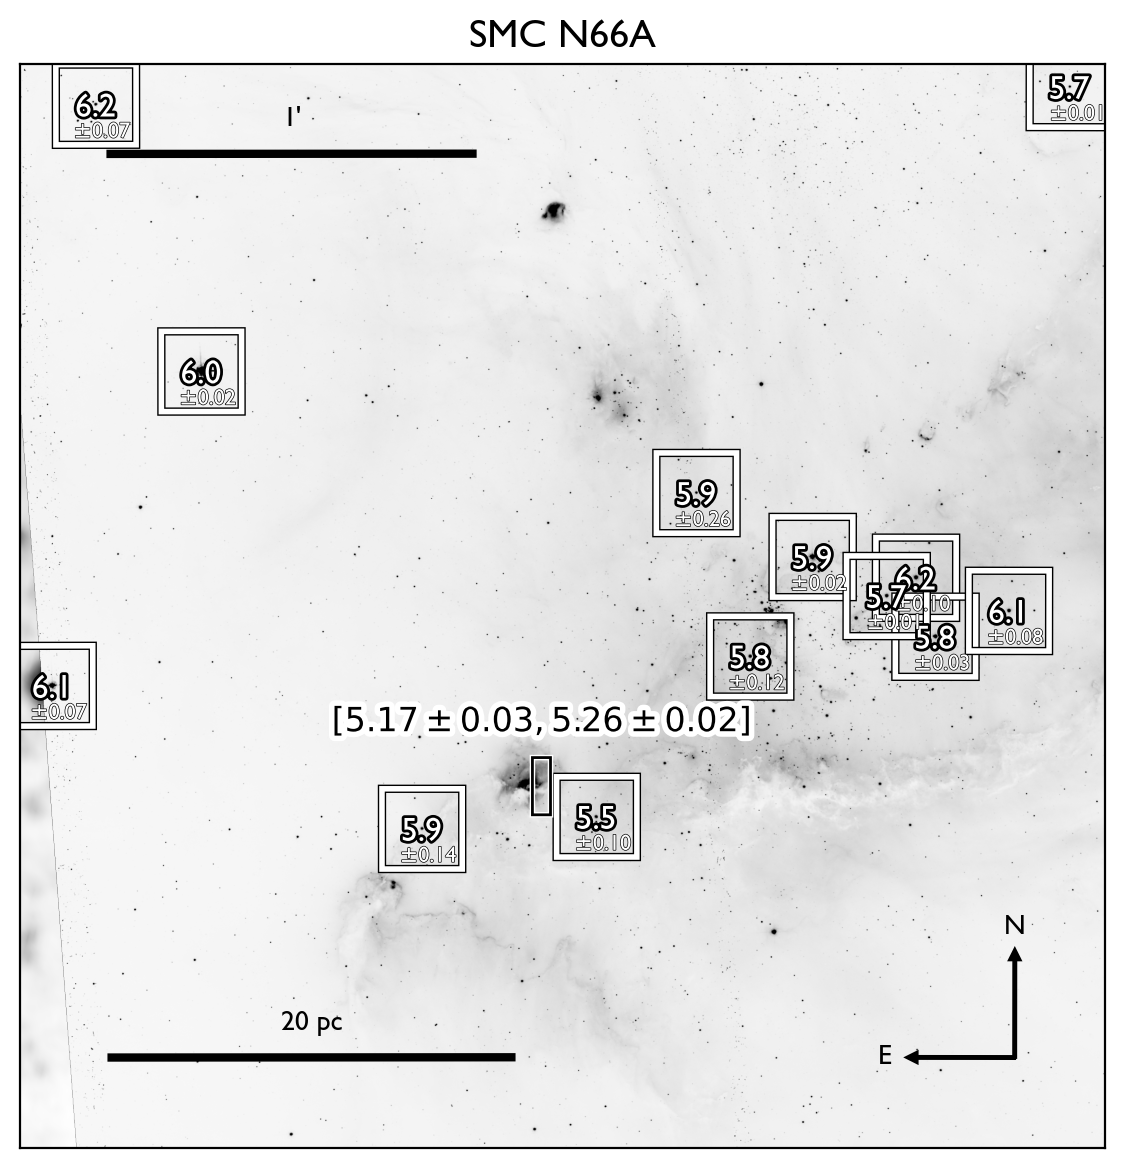

In [11]:
selection = 2

i = 0
for region_name in os.listdir(galaxy_directory):
    region_path = galaxy_directory / region_name
    if region_path.name.startswith(".") or not region_path.is_dir():
        continue
    if i == selection:
        
        df_Fe_cur = df_Fe[df_Fe["Region"] == region_name].copy()
        region_query = Simbad.query_object(region_name)
        ra_region = region_query["ra"][0]
        dec_region = region_query["dec"][0]

        region_position = SkyCoord(ra = ra_region * u.deg, dec = dec_region * u.deg, frame = "icrs")

        hdu_list = fits.open("/Users/billyli/Documents/backups/j92fa3010_drz.fits")

        slit_position = SkyCoord('00h59m14.3s', '-72d11m02.8s', frame = 'icrs')
        hdu_list_background = hips2fits.query(hips = "CDS/P/DSS2/red", width = 3000, height = 3000, projection = "TAN", ra = slit_position.ra - 0.06 * u.arcmin / np.cos(np.deg2rad(slit_position.dec.deg)), dec = slit_position.dec + 0.5 * u.arcmin, fov = Angle(3 * u.arcmin), format = "fits")

        hdu = hdu_list[1]
        hdu_background = hdu_list_background[0]
        wcs = WCS(hdu.header)

        north_up_header = make_north_up_header(hdu_background)
        target_wcs = WCS(north_up_header)
        
        array, footprint = reproject_interp(hdu, target_wcs, shape_out = hdu_background.data.shape)
        array_background, _ = reproject_interp(hdu_background, target_wcs, shape_out = hdu_background.data.shape)
        
        fig = plt.figure(figsize = (6, 6), dpi = 200)
        ax = fig.add_subplot(projection = WCS(north_up_header))
        
        ax.imshow(array_background, origin = "lower", cmap = "Greys", zorder = -100)
        ax.imshow(array, origin = "lower", cmap = "Greys", vmax = np.nanpercentile(hdu.data, 99.9))
        
        ra_min = slit_position.ra.deg - 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg)) - 0.06 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        ra_max = slit_position.ra.deg + 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg)) - 0.06 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        dec_min = slit_position.dec.deg - 1.5 / 60 + 0.5 / 60
        dec_max = slit_position.dec.deg + 1.5 / 60 + 0.5 / 60
        
        x_min, y_min = target_wcs.world_to_pixel(SkyCoord(ra = ra_min * u.deg, dec = dec_min * u.deg))
        x_max, y_max = target_wcs.world_to_pixel(SkyCoord(ra = ra_max * u.deg, dec = dec_max * u.deg))

        if galaxy == "LMC": 
            d = 49.97 * 1000
        elif galaxy == "SMC":
            d = 62.1 * 1000

        block_size_degrees = 0.0037

        for _, row in df_Fe_cur.iterrows():
            
            coord = SkyCoord(ra = row["RA"] * u.deg, dec = row["DEC"] * u.deg, frame = "icrs")

            rect = Rectangle((coord.ra.deg - block_size_degrees / 2.0 / np.cos(np.deg2rad(coord.dec.deg)), coord.dec.deg - block_size_degrees / 2.0), block_size_degrees / np.cos(np.deg2rad(coord.dec.deg)), block_size_degrees, linewidth = 2, edgecolor = "white", facecolor = "none", transform = ax.get_transform("world"))
            rect.set_path_effects([PathEffects.withStroke(linewidth = 3, foreground = "black")])
            ax.add_patch(rect)
            txt = ax.text(coord.ra.deg + 0.0001, coord.dec.deg - 0.0002, f"{row["FeII_H"]:.1f}", fontsize = 12, color = "white", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
            txt.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "black")])
            txt_small = ax.text(coord.ra.deg - 0.001, coord.dec.deg - 0.0013, r"$\pm$" + f"{row["sigma_FeII_H"]:.2f}", color = "white", fontsize = 8, ha = "center", va = "center", transform = ax.get_transform("world"))
            txt_small.set_path_effects([PathEffects.withStroke(linewidth = 0.5, foreground = "black")])
        
        block_width = 3 / 3600
        block_height = 9.5 / 3600

        slit_position_x_correction = 0
        slit_position_y_correction = 0

        big_rect = Rectangle((slit_position.ra.deg - block_width / 2.0 / np.cos(np.deg2rad(coord.dec.deg)) + slit_position_x_correction, slit_position.dec.deg - block_height / 2.0 + slit_position_y_correction), block_width / np.cos(np.deg2rad(coord.dec.deg)), block_height, linewidth = 1, edgecolor = "black", facecolor = "none", angle = 0, transform = ax.get_transform("world"))
        big_rect.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "white")])
        ax.add_patch(big_rect)

        text = ax.text(slit_position.ra.deg + slit_position_x_correction, slit_position.dec.deg + slit_position_y_correction + 0.003, r"$[5.17\pm0.03, 5.26\pm0.02]$", fontsize = 12, color = "black", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        text.set_path_effects([PathEffects.withStroke(linewidth = 4, foreground = "white")])

        scalebar_length = 20
        scalebar_length_degrees = (scalebar_length / d) * (180.0 / np.pi)
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_length_degrees / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_length_degrees / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_length} pc", color = "black", fontsize = 10, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))

        scalebar_angle_length = 1
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_max - 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_angle_length / 60 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_angle_length / 60 / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_angle_length}'", color = "black", fontsize = 10, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))
        
        arrow_x, arrow_y = ra_min + 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60

        arrow_north = FancyArrow(arrow_x, arrow_y, 0, 0.3 / 60, transform = ax.get_transform("world"), width = 0.0001 / np.cos(np.deg2rad(region_position.dec.deg)), head_width = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), head_length = 0.0005, length_includes_head = True, color = "black", clip_on = False)
        arrow_east = FancyArrow(arrow_x, arrow_y, 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), 0, transform = ax.get_transform("world"), width = 0.0001, head_width = 0.0005, head_length = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), length_includes_head = True, color = "black", clip_on = False)
        
        ax.add_patch(arrow_north)
        ax.add_patch(arrow_east)

        ax.text(arrow_x, arrow_y + 0.3 / 60 + 0.001, "N", color = "black", fontsize = 10, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        ax.text(arrow_x + 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)) + 0.001 / np.cos(np.deg2rad(region_position.dec.deg)), arrow_y, "E", color = "black", fontsize = 10, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))

        ax.set_aspect("equal")
        ax.set_title(r"SMC N66A")
        
        for coord in ax.coords:
            coord.set_ticks_visible(False)
            coord.set_ticklabel_visible(False)
            coord.set_axislabel("")

        ax.set_xlim(x_max, x_min)
        ax.set_ylim(y_min, y_max)
            
        plt.tight_layout()
        plt.savefig('SMC N66A.png', dpi = 300)
        plt.show()
        
    i += 1

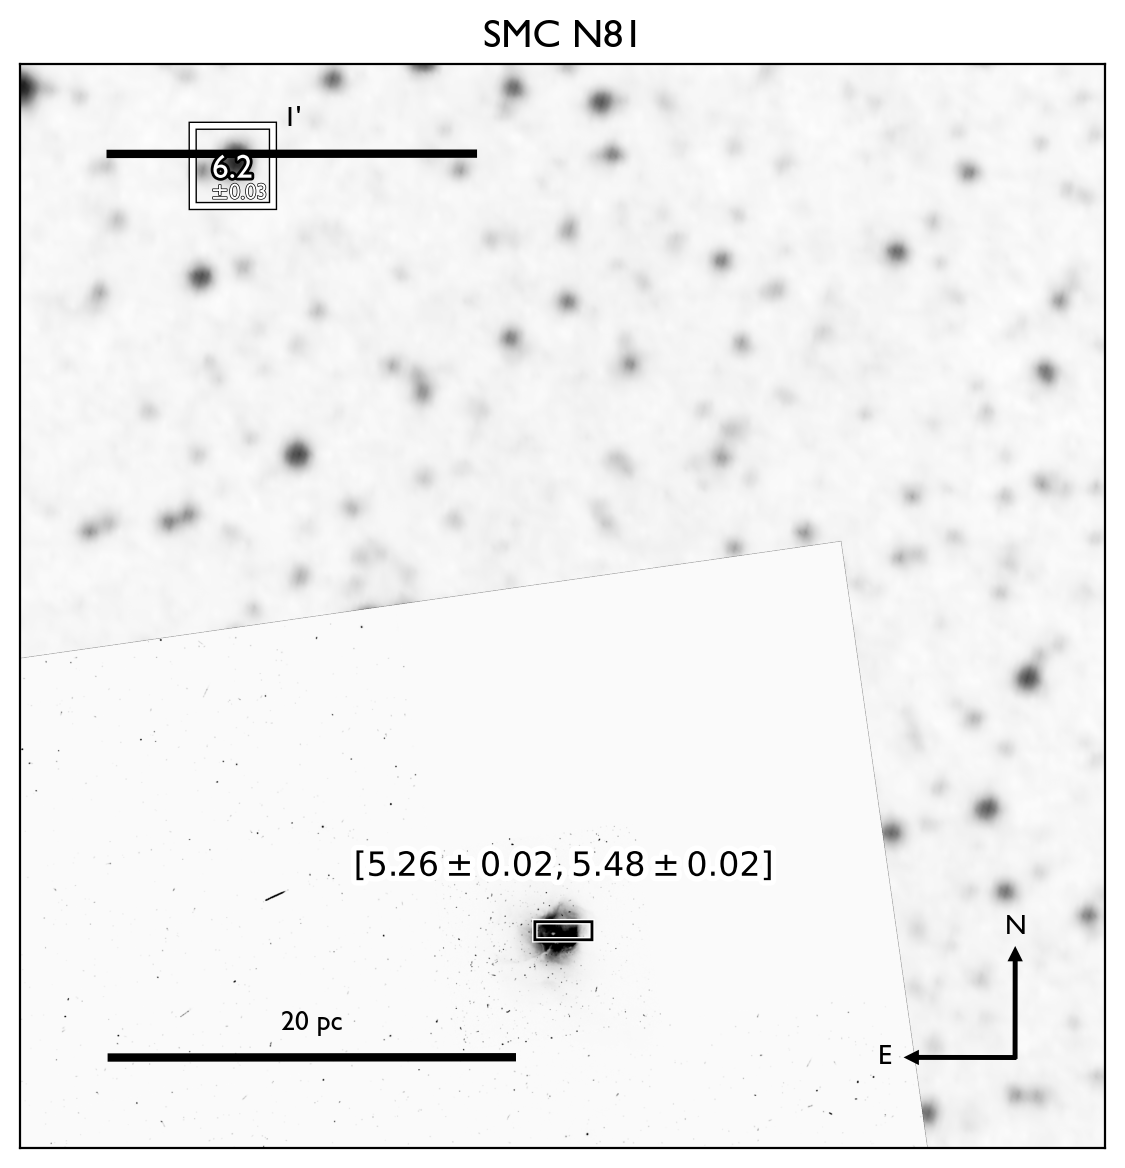

In [12]:
selection = 3

i = 0
for region_name in os.listdir(galaxy_directory):
    region_path = galaxy_directory / region_name
    if region_path.name.startswith(".") or not region_path.is_dir():
        continue
    if i == selection:
        
        df_Fe_cur = df_Fe[df_Fe["Region"] == region_name].copy()
        region_query = Simbad.query_object(region_name)
        ra_region = region_query["ra"][0]
        dec_region = region_query["dec"][0]

        region_position = SkyCoord(ra = ra_region * u.deg, dec = dec_region * u.deg, frame = "icrs")

        hdu_list = fits.open("/Users/billyli/Documents/backups/u3yo0203r_drz.fits")

        slit_position = SkyCoord('01h09m12.8s', '−73d11m36.90s', frame = 'icrs')
        hdu_list_background = hips2fits.query(hips = "CDS/P/DSS2/red", width = 3000, height = 3000, projection = "TAN", ra = slit_position.ra, dec = slit_position.dec + 0.9 * u.arcmin, fov = Angle(3 * u.arcmin), format = "fits")

        hdu = hdu_list[1]
        hdu_background = hdu_list_background[0]
        wcs = WCS(hdu.header)

        north_up_header = make_north_up_header(hdu_background)
        target_wcs = WCS(north_up_header)
        
        array, footprint = reproject_interp(hdu, target_wcs, shape_out = hdu_background.data.shape)
        array_background, _ = reproject_interp(hdu_background, target_wcs, shape_out = hdu_background.data.shape)
        
        fig = plt.figure(figsize = (6, 6), dpi = 200)
        ax = fig.add_subplot(projection = WCS(north_up_header))
        
        ax.imshow(array_background, origin = "lower", cmap = "Greys", zorder = -100)
        ax.imshow(array, origin = "lower", cmap = "Greys", vmax = np.nanpercentile(hdu.data, 99.9))
        
        ra_min = slit_position.ra.deg - 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        ra_max = slit_position.ra.deg + 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        dec_min = slit_position.dec.deg - 1.5 / 60 + 0.9 / 60
        dec_max = slit_position.dec.deg + 1.5 / 60 + 0.9 / 60
        
        x_min, y_min = target_wcs.world_to_pixel(SkyCoord(ra = ra_min * u.deg, dec = dec_min * u.deg))
        x_max, y_max = target_wcs.world_to_pixel(SkyCoord(ra = ra_max * u.deg, dec = dec_max * u.deg))

        if galaxy == "LMC": 
            d = 49.97 * 1000
        elif galaxy == "SMC":
            d = 62.1 * 1000

        block_size_degrees = 0.0037

        for _, row in df_Fe_cur.iterrows():
            
            coord = SkyCoord(ra = row["RA"] * u.deg, dec = row["DEC"] * u.deg, frame = "icrs")

            rect = Rectangle((coord.ra.deg - block_size_degrees / 2.0 / np.cos(np.deg2rad(coord.dec.deg)), coord.dec.deg - block_size_degrees / 2.0), block_size_degrees / np.cos(np.deg2rad(coord.dec.deg)), block_size_degrees, linewidth = 2, edgecolor = "white", facecolor = "none", transform = ax.get_transform("world"), clip_on = False)
            rect.set_path_effects([PathEffects.withStroke(linewidth = 3, foreground = "black")])
            ax.add_patch(rect)
            txt = ax.text(coord.ra.deg + 0.0001, coord.dec.deg - 0.0002, f"{row["FeII_H"]:.1f}", fontsize = 12, color = "white", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world")) # adjusted for centering
            txt.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "black")])
            txt_small = ax.text(coord.ra.deg - 0.001, coord.dec.deg - 0.0013, r"$\pm$" + f"{row["sigma_FeII_H"]:.2f}", color = "white", fontsize = 8, ha = "center", va = "center", transform = ax.get_transform("world")) # adjusted for centering
            txt_small.set_path_effects([PathEffects.withStroke(linewidth = 0.5, foreground = "black")])
        
        block_width = 9.5 / 3600
        block_height = 3 / 3600

        slit_position_x_correction = 0
        slit_position_y_correction = 0

        big_rect = Rectangle((slit_position.ra.deg - block_width / 2.0 / np.cos(np.deg2rad(coord.dec.deg)) + slit_position_x_correction, slit_position.dec.deg - block_height / 2.0 + slit_position_y_correction), block_width / np.cos(np.deg2rad(coord.dec.deg)), block_height, linewidth = 1, edgecolor = "black", facecolor = "none", angle = 0, transform = ax.get_transform("world"), clip_on = False)
        big_rect.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "white")])
        ax.add_patch(big_rect)

        text = ax.text(slit_position.ra.deg + slit_position_x_correction, slit_position.dec.deg + slit_position_y_correction + 0.003, r"$[5.26\pm0.02, 5.48\pm0.02]$", fontsize = 12, color = "black", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        text.set_path_effects([PathEffects.withStroke(linewidth = 4, foreground = "white")])
        
        ax.set_aspect("equal")
        ax.set_title(r"SMC N81")

        scalebar_length = 20
        scalebar_length_degrees = (scalebar_length / d) * (180.0 / np.pi)
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_length_degrees / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_length_degrees / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_length} pc", color = "black", fontsize = 10, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))

        scalebar_angle_length = 1
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_max - 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_angle_length / 60 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_angle_length / 60 / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_angle_length}'", color = "black", fontsize = 10, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))
        
        arrow_x, arrow_y = ra_min + 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60

        arrow_north = FancyArrow(arrow_x, arrow_y, 0, 0.3 / 60, transform = ax.get_transform("world"), width = 0.0001 / np.cos(np.deg2rad(region_position.dec.deg)), head_width = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), head_length = 0.0005, length_includes_head = True, color = "black", clip_on = False)
        arrow_east = FancyArrow(arrow_x, arrow_y, 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), 0, transform = ax.get_transform("world"), width = 0.0001, head_width = 0.0005, head_length = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), length_includes_head = True, color = "black", clip_on = False)
        
        ax.add_patch(arrow_north)
        ax.add_patch(arrow_east)

        ax.text(arrow_x, arrow_y + 0.3 / 60 + 0.001, "N", color = "black", fontsize = 10, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        ax.text(arrow_x + 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)) + 0.001 / np.cos(np.deg2rad(region_position.dec.deg)), arrow_y, "E", color = "black", fontsize = 10, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        
        for coord in ax.coords:
            coord.set_ticks_visible(False)
            coord.set_ticklabel_visible(False)
            coord.set_axislabel("")

        ax.set_xlim(x_max, x_min)
        ax.set_ylim(y_min, y_max)

        plt.tight_layout()
        plt.savefig('SMC N81.png', dpi = 300)
        plt.show()
        
    i += 1

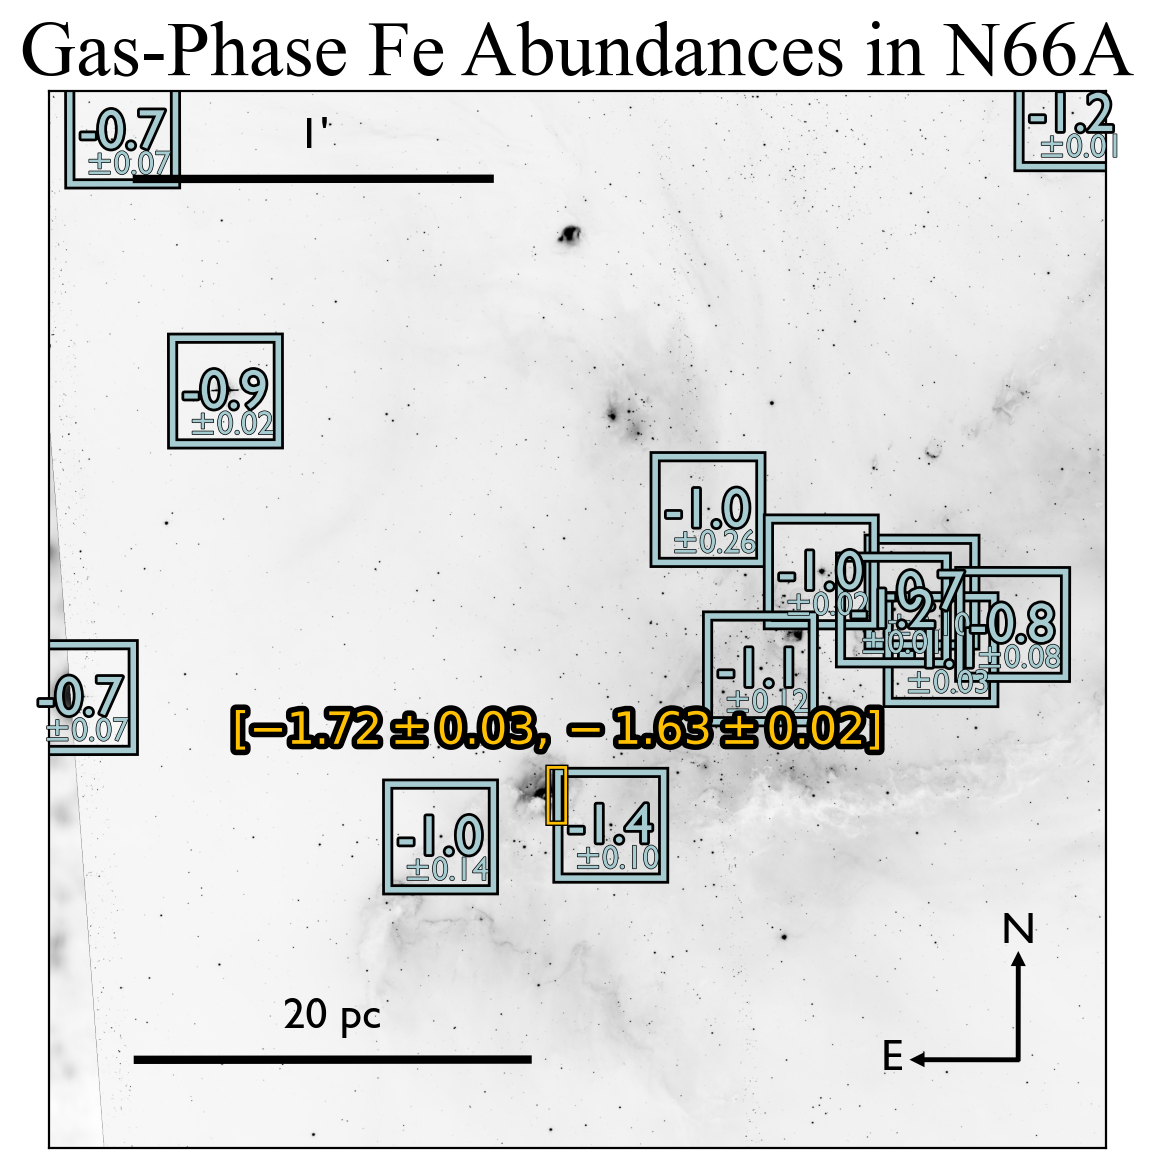

In [13]:
font = {'family' : 'gill sans',
         'size'   : 12,
         'serif':  'cmr10'
         }

plt.rc('font', **font)
plt.rc('axes', unicode_minus = False)

selection = 2

i = 0
for region_name in os.listdir(galaxy_directory):
    region_path = galaxy_directory / region_name
    if region_path.name.startswith(".") or not region_path.is_dir():
        continue
    if i == selection:
        
        df_Fe_cur = df_Fe[df_Fe["Region"] == region_name].copy()
        region_query = Simbad.query_object(region_name)
        ra_region = region_query["ra"][0]
        dec_region = region_query["dec"][0]

        region_position = SkyCoord(ra = ra_region * u.deg, dec = dec_region * u.deg, frame = "icrs")

        hdu_list = fits.open("/Users/billyli/Documents/backups/j92fa3010_drz.fits")

        slit_position = SkyCoord('00h59m14.3s', '-72d11m02.8s', frame = 'icrs')
        hdu_list_background = hips2fits.query(hips = "CDS/P/DSS2/red", width = 3000, height = 3000, projection = "TAN", ra = slit_position.ra - 0.06 * u.arcmin / np.cos(np.deg2rad(slit_position.dec.deg)), dec = slit_position.dec + 0.5 * u.arcmin, fov = Angle(3 * u.arcmin), format = "fits")

        hdu = hdu_list[1]
        hdu_background = hdu_list_background[0]
        wcs = WCS(hdu.header)

        north_up_header = make_north_up_header(hdu_background)
        target_wcs = WCS(north_up_header)
        
        array, footprint = reproject_interp(hdu, target_wcs, shape_out = hdu_background.data.shape)
        array_background, _ = reproject_interp(hdu_background, target_wcs, shape_out = hdu_background.data.shape)
        
        fig = plt.figure(figsize = (6, 6), dpi = 200)
        ax = fig.add_subplot(projection = WCS(north_up_header))
        
        ax.imshow(array_background, origin = "lower", cmap = "Greys", zorder = -100)
        ax.imshow(array, origin = "lower", cmap = "Greys", vmax = np.nanpercentile(hdu.data, 99.9))
        
        ra_min = slit_position.ra.deg - 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg)) - 0.06 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        ra_max = slit_position.ra.deg + 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg)) - 0.06 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        dec_min = slit_position.dec.deg - 1.5 / 60 + 0.5 / 60
        dec_max = slit_position.dec.deg + 1.5 / 60 + 0.5 / 60
        
        x_min, y_min = target_wcs.world_to_pixel(SkyCoord(ra = ra_min * u.deg, dec = dec_min * u.deg))
        x_max, y_max = target_wcs.world_to_pixel(SkyCoord(ra = ra_max * u.deg, dec = dec_max * u.deg))

        if galaxy == "LMC": 
            d = 49.97 * 1000
        elif galaxy == "SMC":
            d = 62.1 * 1000

        block_size_degrees = 0.005

        for _, row in df_Fe_cur.iterrows():
            
            coord = SkyCoord(ra = row["RA"] * u.deg, dec = row["DEC"] * u.deg, frame = "icrs")

            rect = Rectangle((coord.ra.deg - block_size_degrees / 2.0 / np.cos(np.deg2rad(coord.dec.deg)), coord.dec.deg - block_size_degrees / 2.0), block_size_degrees / np.cos(np.deg2rad(coord.dec.deg)), block_size_degrees, linewidth = 2, edgecolor = "#A6CCD1", facecolor = "none", transform = ax.get_transform("world"))
            rect.set_path_effects([PathEffects.withStroke(linewidth = 4, foreground = "black")])
            ax.add_patch(rect)
            txt = ax.text(coord.ra.deg + 0.0001, coord.dec.deg - 0.0002, f"{(row["FeII_H"] - 6.89):.1f}", fontsize = 20, color = "#A6CCD1", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
            txt.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "black")])
            txt_small = ax.text(coord.ra.deg - 0.001, coord.dec.deg - 0.0017, r"$\pm$" + f"{row["sigma_FeII_H"]:.2f}", color = "#A6CCD1", fontsize = 12, ha = "center", va = "center", transform = ax.get_transform("world"))
            txt_small.set_path_effects([PathEffects.withStroke(linewidth = 0.5, foreground = "black")])
        
        block_width = 3 / 3600
        block_height = 9.5 / 3600

        slit_position_x_correction = 0
        slit_position_y_correction = 0

        big_rect = Rectangle((slit_position.ra.deg - block_width / 2.0 / np.cos(np.deg2rad(coord.dec.deg)) + slit_position_x_correction, slit_position.dec.deg - block_height / 2.0 + slit_position_y_correction), block_width / np.cos(np.deg2rad(coord.dec.deg)), block_height, linewidth = 1, edgecolor = "#FFC000", facecolor = "none", angle = 0, transform = ax.get_transform("world"))
        big_rect.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "black")])
        ax.add_patch(big_rect)

        text = ax.text(slit_position.ra.deg + slit_position_x_correction, slit_position.dec.deg + slit_position_y_correction + 0.003, r"$[-1.72\pm0.03, -1.63\pm0.02]$", fontsize = 16, color = "#FFC000", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        text.set_path_effects([PathEffects.withStroke(linewidth = 4, foreground = "black")])

        scalebar_length = 20
        scalebar_length_degrees = (scalebar_length / d) * (180.0 / np.pi)
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_length_degrees / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_length_degrees / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_length} pc", color = "black", fontsize = 16, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))

        scalebar_angle_length = 1
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_max - 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_angle_length / 60 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_angle_length / 60 / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_angle_length}'", color = "black", fontsize = 16, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))
        
        arrow_x, arrow_y = ra_min + 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60

        arrow_north = FancyArrow(arrow_x, arrow_y, 0, 0.3 / 60, transform = ax.get_transform("world"), width = 0.0001 / np.cos(np.deg2rad(region_position.dec.deg)), head_width = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), head_length = 0.0005, length_includes_head = True, color = "black", clip_on = False)
        arrow_east = FancyArrow(arrow_x, arrow_y, 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), 0, transform = ax.get_transform("world"), width = 0.0001, head_width = 0.0005, head_length = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), length_includes_head = True, color = "black", clip_on = False)
        
        ax.add_patch(arrow_north)
        ax.add_patch(arrow_east)

        ax.text(arrow_x, arrow_y + 0.3 / 60 + 0.001, "N", color = "black", fontsize = 16, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        ax.text(arrow_x + 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)) + 0.001 / np.cos(np.deg2rad(region_position.dec.deg)), arrow_y, "E", color = "black", fontsize = 16, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        
        ax.set_title(r"Gas-Phase Fe Abundances in N66A", fontname = "Times New Roman", fontsize = 28)
        
        for coord in ax.coords:
            coord.set_ticks_visible(False)
            coord.set_ticklabel_visible(False)
            coord.set_axislabel("")

        ax.set_xlim(x_max, x_min)
        ax.set_ylim(y_min, y_max)
            
        plt.tight_layout()
        plt.savefig('Figure 1.2.png', dpi = 300)
        plt.show()
        
    i += 1

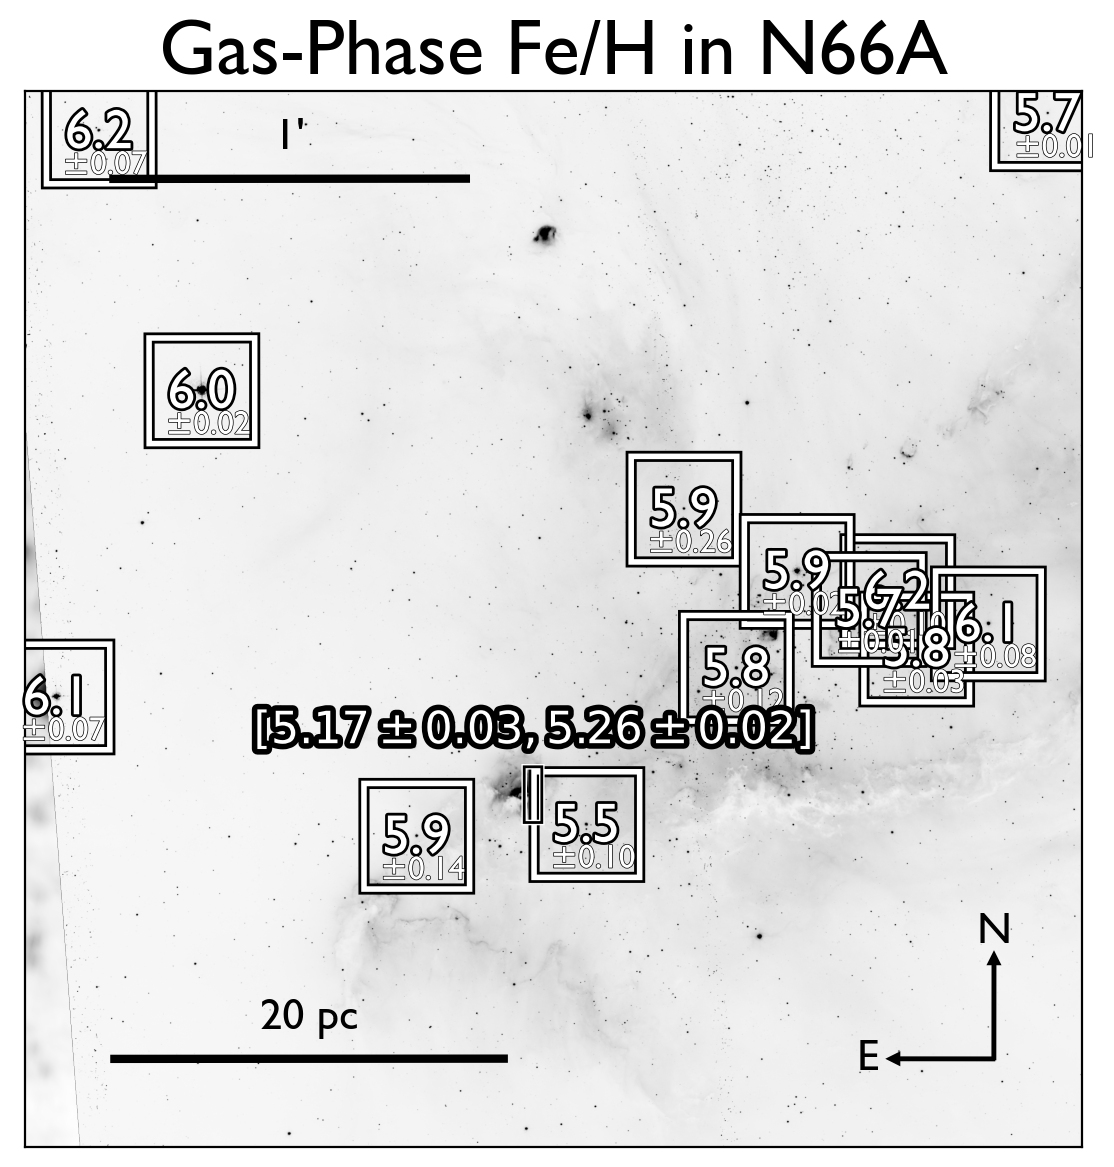

In [21]:
font = {'family' : 'gill sans',
         'size'   : 12,
         'serif':  'cmr10'
         }

plt.rc('font', **font)
plt.rc('axes', unicode_minus = False)

selection = 2

i = 0
for region_name in os.listdir(galaxy_directory):
    region_path = galaxy_directory / region_name
    if region_path.name.startswith(".") or not region_path.is_dir():
        continue
    if i == selection:
        
        df_Fe_cur = df_Fe[df_Fe["Region"] == region_name].copy()
        region_query = Simbad.query_object(region_name)
        ra_region = region_query["ra"][0]
        dec_region = region_query["dec"][0]

        region_position = SkyCoord(ra = ra_region * u.deg, dec = dec_region * u.deg, frame = "icrs")

        hdu_list = fits.open("/Users/billyli/Documents/backups/j92fa3010_drz.fits")

        slit_position = SkyCoord('00h59m14.3s', '-72d11m02.8s', frame = 'icrs')
        hdu_list_background = hips2fits.query(hips = "CDS/P/DSS2/red", width = 3000, height = 3000, projection = "TAN", ra = slit_position.ra - 0.06 * u.arcmin / np.cos(np.deg2rad(slit_position.dec.deg)), dec = slit_position.dec + 0.5 * u.arcmin, fov = Angle(3 * u.arcmin), format = "fits")

        hdu = hdu_list[1]
        hdu_background = hdu_list_background[0]
        wcs = WCS(hdu.header)

        north_up_header = make_north_up_header(hdu_background)
        target_wcs = WCS(north_up_header)
        
        array, footprint = reproject_interp(hdu, target_wcs, shape_out = hdu_background.data.shape)
        array_background, _ = reproject_interp(hdu_background, target_wcs, shape_out = hdu_background.data.shape)
        
        fig = plt.figure(figsize = (6, 6), dpi = 200)
        ax = fig.add_subplot(projection = WCS(north_up_header))
        
        ax.imshow(array_background, origin = "lower", cmap = "Greys", zorder = -100)
        ax.imshow(array, origin = "lower", cmap = "Greys", vmax = np.nanpercentile(hdu.data, 99.9))
        
        ra_min = slit_position.ra.deg - 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg)) - 0.06 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        ra_max = slit_position.ra.deg + 1.5 / 60 / np.cos(np.deg2rad(slit_position.dec.deg)) - 0.06 / 60 / np.cos(np.deg2rad(slit_position.dec.deg))
        dec_min = slit_position.dec.deg - 1.5 / 60 + 0.5 / 60
        dec_max = slit_position.dec.deg + 1.5 / 60 + 0.5 / 60
        
        x_min, y_min = target_wcs.world_to_pixel(SkyCoord(ra = ra_min * u.deg, dec = dec_min * u.deg))
        x_max, y_max = target_wcs.world_to_pixel(SkyCoord(ra = ra_max * u.deg, dec = dec_max * u.deg))

        if galaxy == "LMC": 
            d = 49.97 * 1000
        elif galaxy == "SMC":
            d = 62.1 * 1000

        block_size_degrees = 0.005

        for _, row in df_Fe_cur.iterrows():
            
            coord = SkyCoord(ra = row["RA"] * u.deg, dec = row["DEC"] * u.deg, frame = "icrs")

            rect = Rectangle((coord.ra.deg - block_size_degrees / 2.0 / np.cos(np.deg2rad(coord.dec.deg)), coord.dec.deg - block_size_degrees / 2.0), block_size_degrees / np.cos(np.deg2rad(coord.dec.deg)), block_size_degrees, linewidth = 2, edgecolor = "white", facecolor = "none", transform = ax.get_transform("world"))
            rect.set_path_effects([PathEffects.withStroke(linewidth = 4, foreground = "black")])
            ax.add_patch(rect)
            txt = ax.text(coord.ra.deg + 0.0001, coord.dec.deg - 0.0002, f"{(row["FeII_H"]):.1f}", fontsize = 20, color = "white", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
            txt.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "black")])
            txt_small = ax.text(coord.ra.deg - 0.001, coord.dec.deg - 0.0017, r"$\pm$" + f"{row["sigma_FeII_H"]:.2f}", color = "white", fontsize = 12, ha = "center", va = "center", transform = ax.get_transform("world"))
            txt_small.set_path_effects([PathEffects.withStroke(linewidth = 0.5, foreground = "black")])
        
        block_width = 3 / 3600
        block_height = 9.5 / 3600

        slit_position_x_correction = 0
        slit_position_y_correction = 0

        big_rect = Rectangle((slit_position.ra.deg - block_width / 2.0 / np.cos(np.deg2rad(coord.dec.deg)) + slit_position_x_correction, slit_position.dec.deg - block_height / 2.0 + slit_position_y_correction), block_width / np.cos(np.deg2rad(coord.dec.deg)), block_height, linewidth = 1, edgecolor = "black", facecolor = "none", angle = 0, transform = ax.get_transform("world"))
        big_rect.set_path_effects([PathEffects.withStroke(linewidth = 2, foreground = "white")])
        ax.add_patch(big_rect)

        text = ax.text(slit_position.ra.deg + slit_position_x_correction, slit_position.dec.deg + slit_position_y_correction + 0.003, r"$[5.17\pm0.03, 5.26\pm0.02]$", fontsize = 16, color = "white", ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        text.set_path_effects([PathEffects.withStroke(linewidth = 4, foreground = "black")])

        scalebar_length = 20
        scalebar_length_degrees = (scalebar_length / d) * (180.0 / np.pi)
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_length_degrees / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_length_degrees / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_length} pc", color = "black", fontsize = 16, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))

        scalebar_angle_length = 1
        scalebar_x, scalebar_y = ra_max - 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_max - 0.25 / 60
        
        ax.plot([scalebar_x - scalebar_angle_length / 60 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_x], [scalebar_y, scalebar_y], color = "black", lw = 3, transform = ax.get_transform("world"))
        ax.text(scalebar_x - scalebar_angle_length / 60 / 2.0 / np.cos(np.deg2rad(region_position.dec.deg)), scalebar_y + 0.001, f"{scalebar_angle_length}'", color = "black", fontsize = 16, ha = "center", va = "bottom", weight = "bold", transform = ax.get_transform("world"))
        
        arrow_x, arrow_y = ra_min + 0.25 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), dec_min + 0.25 / 60

        arrow_north = FancyArrow(arrow_x, arrow_y, 0, 0.3 / 60, transform = ax.get_transform("world"), width = 0.0001 / np.cos(np.deg2rad(region_position.dec.deg)), head_width = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), head_length = 0.0005, length_includes_head = True, color = "black", clip_on = False)
        arrow_east = FancyArrow(arrow_x, arrow_y, 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)), 0, transform = ax.get_transform("world"), width = 0.0001, head_width = 0.0005, head_length = 0.0005 / np.cos(np.deg2rad(region_position.dec.deg)), length_includes_head = True, color = "black", clip_on = False)
        
        ax.add_patch(arrow_north)
        ax.add_patch(arrow_east)

        ax.text(arrow_x, arrow_y + 0.3 / 60 + 0.001, "N", color = "black", fontsize = 16, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        ax.text(arrow_x + 0.3 / 60 / np.cos(np.deg2rad(region_position.dec.deg)) + 0.001 / np.cos(np.deg2rad(region_position.dec.deg)), arrow_y, "E", color = "black", fontsize = 16, ha = "center", va = "center", weight = "bold", transform = ax.get_transform("world"))
        
        ax.set_title(r"Gas-Phase Fe/H in N66A", fontsize = 28)
        
        for coord in ax.coords:
            coord.set_ticks_visible(False)
            coord.set_ticklabel_visible(False)
            coord.set_axislabel("")

        ax.set_xlim(x_max, x_min)
        ax.set_ylim(y_min, y_max)
            
        plt.tight_layout()
        plt.savefig('Zine Figure.png', dpi = 300)
        plt.show()
        
    i += 1

In [15]:
# END